In [1]:
import sys
sys.path.append('..')

import pandas as pd
from datasets.loader import load_files, load_npy_file, load_json_file
from evaluation.visualization import plot_histories
import matplotlib.pyplot as plt
from datasets.paths import ProjectPaths
import math


c:\Users\malos\Documents\GitHub\JustShare\server\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
pd.set_option("display.max_columns", None)


In [3]:
paths = ProjectPaths()


In [4]:
histories = load_files(paths.models_dir, "history.npy", load_npy_file)
print(histories.keys())


dict_keys(['bilstm_mean_cosine', 'bilstm_mean_cosine_aug', 'lstm_last_manhattan', 'lstm_mean_cosine', 'lstm_mean_manhattan'])


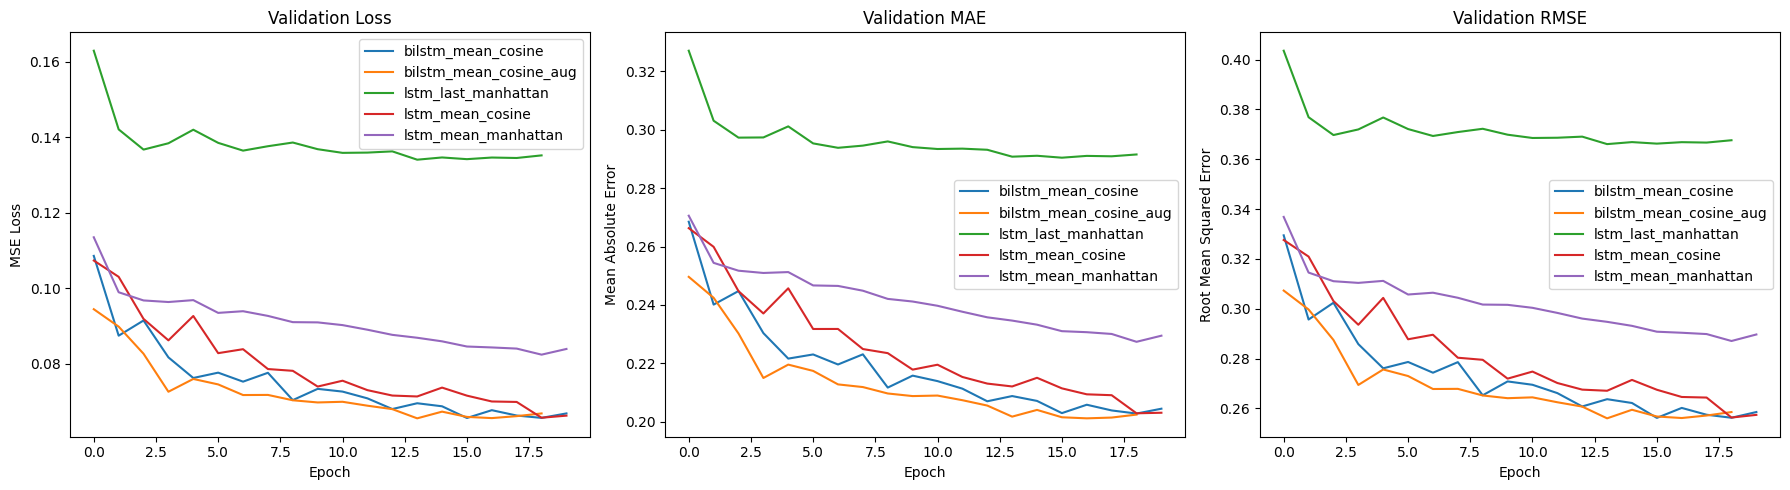

In [5]:
plot_histories(histories, paths.models_dir)


In [ ]:
metrics = load_files(paths.models_dir, "metrics.json", load_json_file)
print(len(metrics))
 

5


In [7]:
df = pd.DataFrame(metrics.values())
display(df)


,name,hidden_dim,embedding_dim,pooling,similarity,bidirectional,mlp_layers,concat_features,mlp_dropout,lstm_dropout,sequence_length,data_augmentation,train_time_s,train_loss,train_mae,val_loss,val_mae,test_pearson,test_spearman,test_mse,test_mae,test_rmse,test_bias,test_r2,calibration_pearson,calibration_spearman,calibration_mse,calibration_mae,calibration_rmse,calibration_bias,calibration_r2
0,bilstm_mean_cosine,64,400,mean,cosine,True,[32],[diff],0.4,0.3,26,False,1334.867168,0.017117,0.104503,0.065638,0.202926,0.688613,0.680023,0.064655,0.198064,0.254273,-0.122884,0.304396,0.697781,0.680323,0.048045,0.172336,0.219192,0.017048,0.483095
1,bilstm_mean_cosine_aug,64,400,mean,cosine,True,[32],[diff],0.4,0.3,26,True,2014.611189,0.012588,0.089526,0.065547,0.201723,0.682294,0.677897,0.063222,0.194847,0.251441,-0.113412,0.319808,0.687587,0.676311,0.049843,0.174390,0.223256,0.025606,0.463752
2,lstm_last_manhattan,64,400,last,manhattan,False,[32],[diff],0.4,0.3,26,False,527.724379,0.085314,0.232724,0.134017,0.290800,0.392217,0.394153,0.121713,0.275011,0.348874,-0.118111,-0.309478,0.407274,0.392324,0.079426,0.238887,0.281826,0.043027,0.145479
3,lstm_mean_cosine,64,400,mean,cosine,False,[32],[diff],0.4,0.3,26,False,564.623533,0.021666,0.118316,0.065709,0.202860,0.665101,0.647171,0.067602,0.203432,0.260005,-0.119340,0.272686,0.665798,0.646272,0.052216,0.180059,0.228508,0.014798,0.438225
4,lstm_mean_manhattan,64,400,mean,manhattan,False,[32],[diff],0.4,0.3,26,False,554.312409,0.045224,0.175794,0.082406,0.227362,0.564008,0.534927,0.074661,0.216957,0.273242,-0.105334,0.196740,0.552956,0.531371,0.066643,0.205913,0.258153,0.040278,0.283006


In [8]:
df["combined"] = df[["test_pearson", "test_spearman"]].mean(axis=1)

df = df.sort_values("combined", ascending=False)

display(df[["name", "test_pearson", "test_spearman", "combined"]])


,name,test_pearson,test_spearman,combined
0,bilstm_mean_cosine,0.688613,0.680023,0.684318
1,bilstm_mean_cosine_aug,0.682294,0.677897,0.680096
3,lstm_mean_cosine,0.665101,0.647171,0.656136
4,lstm_mean_manhattan,0.564008,0.534927,0.549467
2,lstm_last_manhattan,0.392217,0.394153,0.393185


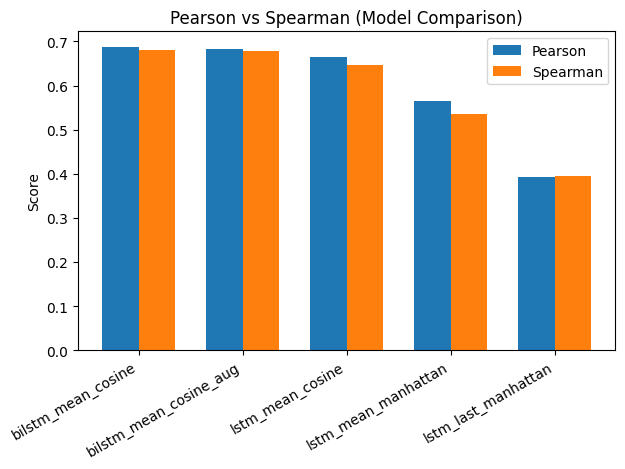

In [9]:
x = range(len(df))
width = 0.35

plt.figure()
plt.bar([i - width/2 for i in x], df["test_pearson"], width=width, label="Pearson")
plt.bar([i + width/2 for i in x], df["test_spearman"], width=width, label="Spearman")

plt.xticks(x, df["name"], rotation=30, ha="right")
plt.ylabel("Score")
plt.title("Pearson vs Spearman (Model Comparison)")
plt.legend()
plt.tight_layout()
plt.show()


In [10]:
# Asigna una clasificación a cada modelo. Una puntuación más alta equivale a una mejor clasificación.
df["pearson_rank"] = df["test_pearson"].rank(ascending=False)
df["spearman_rank"] = df["test_spearman"].rank(ascending=False)

print(df[["name", "pearson_rank", "spearman_rank"]])


                     name  pearson_rank  spearman_rank
0      bilstm_mean_cosine           1.0            1.0
1  bilstm_mean_cosine_aug           2.0            2.0
3        lstm_mean_cosine           3.0            3.0
4     lstm_mean_manhattan           4.0            4.0
2     lstm_last_manhattan           5.0            5.0


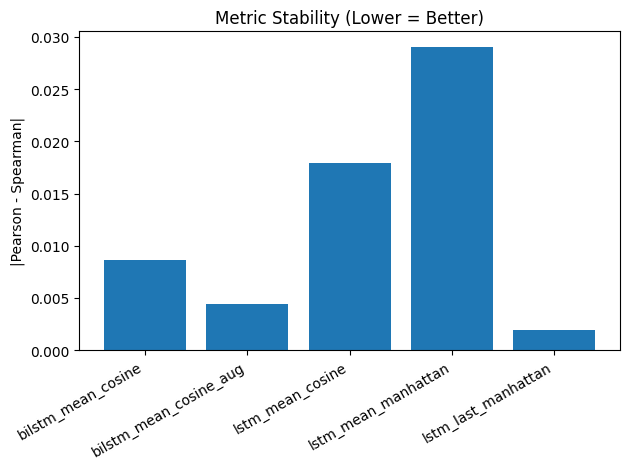

In [11]:
df["gap"] = abs(df["test_pearson"] - df["test_spearman"])

plt.figure()
plt.bar(df["name"], df["gap"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("|Pearson - Spearman|")
plt.title("Metric Stability (Lower = Better)")
plt.tight_layout()
plt.show()


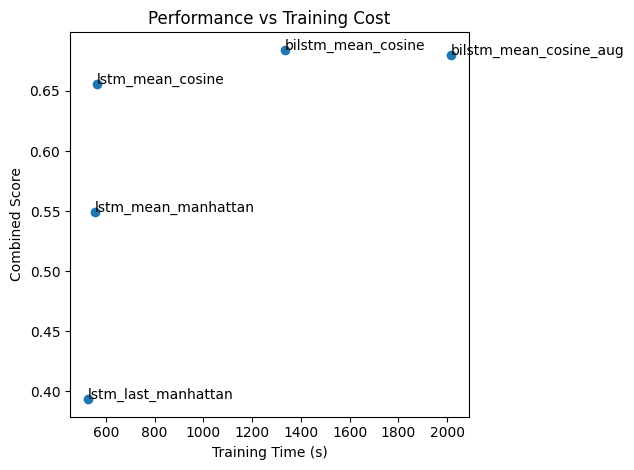

In [12]:
plt.figure()
plt.scatter(df["train_time_s"], df["combined"])

for i, txt in enumerate(df["name"]):
    plt.annotate(txt, (df["train_time_s"].iloc[i], df["combined"].iloc[i]))

plt.xlabel("Training Time (s)")
plt.ylabel("Combined Score")
plt.title("Performance vs Training Cost")
plt.tight_layout()
plt.show()


In [13]:
df["score"] = df["combined"] - df["test_mae"]

df_sorted = df.sort_values("score", ascending=False)

print(df_sorted[["name", "test_pearson", "test_spearman", "test_mae", "score"]])


                     name  test_pearson  test_spearman  test_mae     score
0      bilstm_mean_cosine      0.688613       0.680023  0.198064  0.486255
1  bilstm_mean_cosine_aug      0.682294       0.677897  0.194847  0.485249
3        lstm_mean_cosine      0.665101       0.647171  0.203432  0.452704
4     lstm_mean_manhattan      0.564008       0.534927  0.216957  0.332511
2     lstm_last_manhattan      0.392217       0.394153  0.275011  0.118173


,name,n_win,avg_delta
4,lstm_mean_manhattan,5,0.024409
1,bilstm_mean_cosine_aug,6,0.042497
3,lstm_mean_cosine,6,0.048591
0,bilstm_mean_cosine,7,0.053060
2,lstm_last_manhattan,6,0.098390


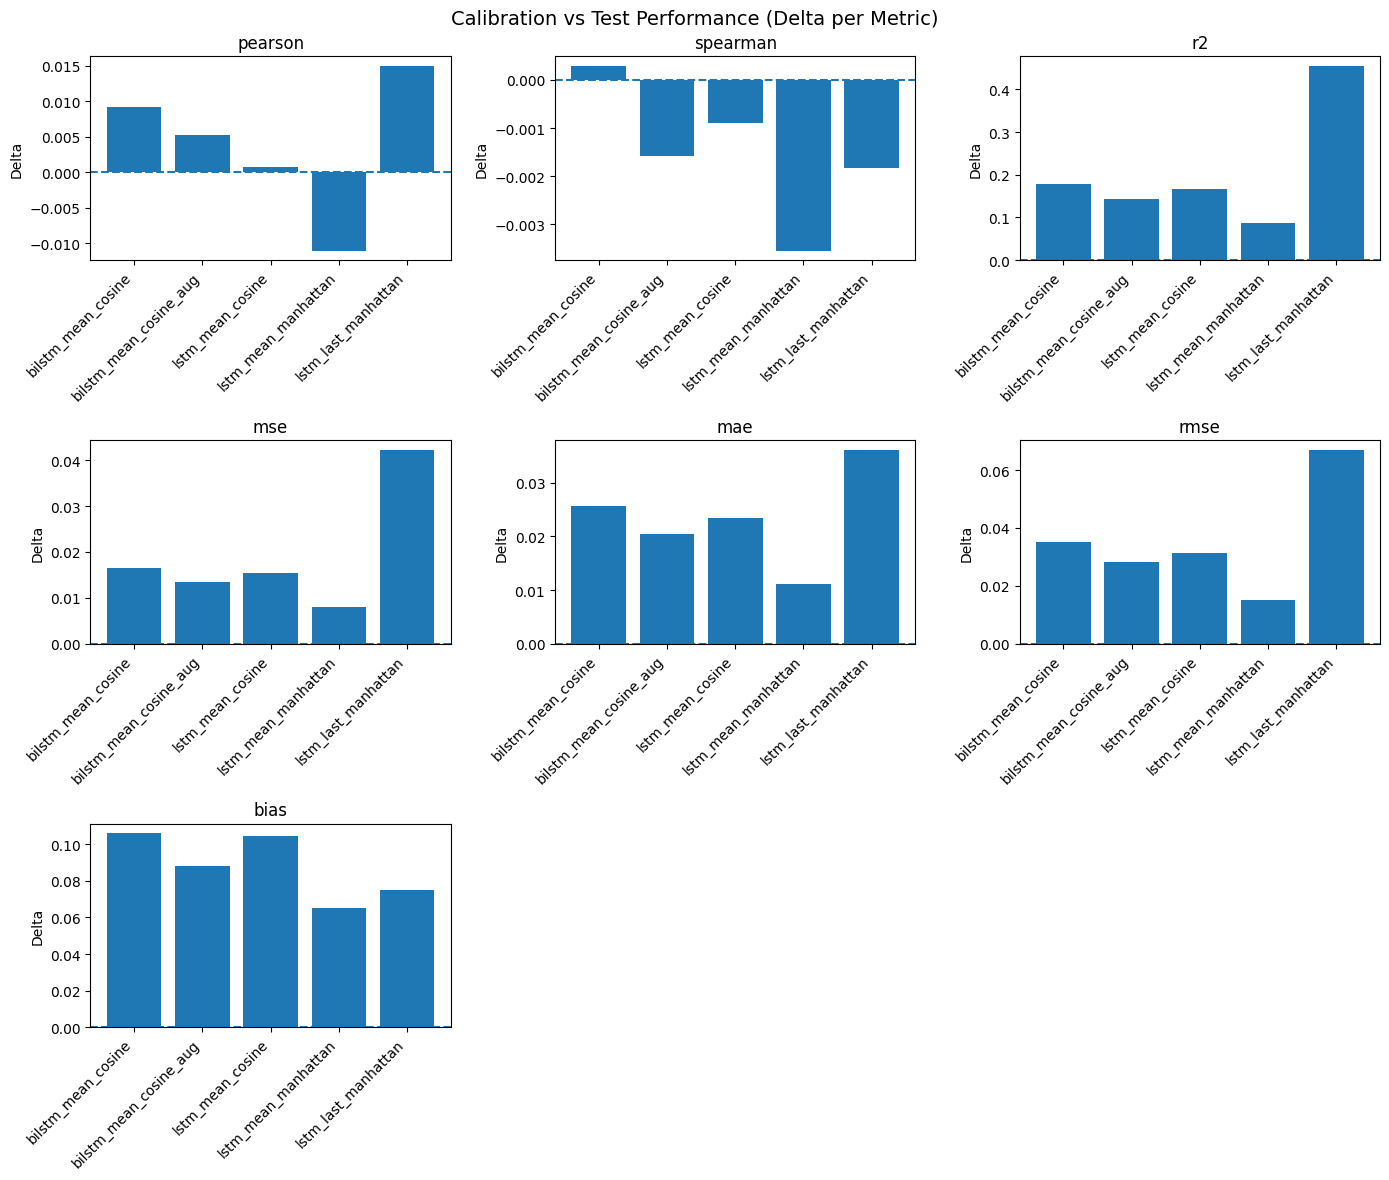

In [14]:
# Más alto --> mejor
pos_metrics = ["pearson", "spearman", "r2"]
# Más bajo --> mejor
neg_metrics = ["mse", "mae", "rmse"]
# Más cerca de 0 --> mejor
special_metrics = ["bias"]

# Cuando la diferencia es positiva, es mejor, de modo que usando calibración para el modelo, mejora ese parámetro.
for metric in pos_metrics:
	df[f"delta_{metric}"] = df[f"calibration_{metric}"] - df[f"test_{metric}"]

for metric in neg_metrics:
	df[f"delta_{metric}"] = df[f"test_{metric}"] - df[f"calibration_{metric}"]

for metric in special_metrics:
	df[f"delta_{metric}"] = abs(df[f"test_{metric}"]) - abs(df[f"calibration_{metric}"])
	
all_metrics = pos_metrics + neg_metrics + special_metrics

for metric in all_metrics:
	df[f"cal_win_{metric}"] = df[f"delta_{metric}"] > 0

df["n_win"] = df[[f"cal_win_{m}" for m in all_metrics]].sum(axis=1)
df["avg_delta"] = df[[f"delta_{m}" for m in all_metrics]].mean(axis=1)
df_ranked = df.sort_values("avg_delta")
display(df_ranked[["name", "n_win", "avg_delta"]])

n_metrics = len(all_metrics)
n_cols = 3
n_rows = math.ceil(n_metrics / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for i, metric in enumerate(all_metrics):
	ax = axes[i]

	ax.bar(df["name"], df[f"delta_{metric}"])
	
	ax.axhline(0, linestyle="--")

	ax.set_title(metric)
	ax.set_ylabel("Delta")

	ax.set_xticks(range(len(df)))
	ax.set_xticklabels(df["name"], rotation=45, ha="right")

for j in range(i + 1, len(axes)):
	fig.delaxes(axes[j])

fig.suptitle("Calibration vs Test Performance (Delta per Metric)", fontsize=14)
plt.tight_layout()
plt.show()
